# Loan Pricing Fairness & Anomaly Detection — Complete Project

**32K Loan Dataset | End-to-End Machine Learning**

### Business objective
Predict the expected interest rate for a borrower, compare actual vs expected pricing, flag potentially unusual pricing, benchmark against comparable loans, and monitor residual differences across borrower segments.

> **Important:** R² is a regression metric, not classification accuracy. An anomaly is an investigation flag, not proof of discrimination.

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_ind
from xgboost import XGBRegressor

Libraries imported successfully.

## 1. Load dataset

In [1]:
df = pd.read_csv("LoanDataset - LoansDatasest.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (32586, 13)


 customer_id  customer_age customer_income home_ownership  employment_duration loan_intent loan_grade  loan_amnt  loan_int_rate  term_years historical_default  cred_hist_length Current_loan_status
         1.0            22           59000           RENT                123.0    PERSONAL          C £35,000.00          16.02          10                  Y                 3             DEFAULT
         2.0            21            9600            OWN                  5.0   EDUCATION          A  £1,000.00          11.14           1                NaN                 2          NO DEFAULT
         3.0            25            9600       MORTGAGE                  1.0     MEDICAL          B  £5,500.00          12.87           5                  N                 3             DEFAULT
         4.0            23           65500           RENT                  4.0     MEDICAL          B £35,000.00          15.23          10                  N                 2             DEFAULT
         5.0   

## 2. Data quality

In [1]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

Missing values by column:
historical_default     20737
loan_int_rate           3116
employment_duration      895
Current_loan_status        4
customer_id                3
loan_amnt                  1
home_ownership             0
customer_age               0
customer_income            0
loan_intent                0
loan_grade                 0
term_years                 0
cred_hist_length           0

Duplicate rows: 6


## 3. Cleaning decisions

- Remove rows with missing `loan_int_rate` because it is the target.
- Convert income and loan amount to numeric.
- Treat missing categorical values as `UNKNOWN`.
- Exclude `customer_id` from the model.
- Exclude `Current_loan_status` from the primary pricing model because it is a post-origination outcome and can introduce temporal leakage.

In [1]:
model_df = df.dropna(subset=["loan_int_rate"]).copy()
for c in ["customer_income","loan_amnt"]:
    model_df[c] = pd.to_numeric(model_df[c].astype(str).str.replace(r"[^0-9.\-]","",regex=True),errors="coerce")
for c in ["home_ownership","loan_intent","loan_grade","historical_default"]:
    model_df[c] = model_df[c].fillna("UNKNOWN")

print("Original rows:", len(df))
print("Rows used for supervised learning:", len(model_df))
print("Rows excluded due to missing target:", len(df)-len(model_df))

Original rows: 32,586
Rows used for supervised learning: 29,470
Rows excluded due to missing target: 3,116


## 4. EDA — target distribution

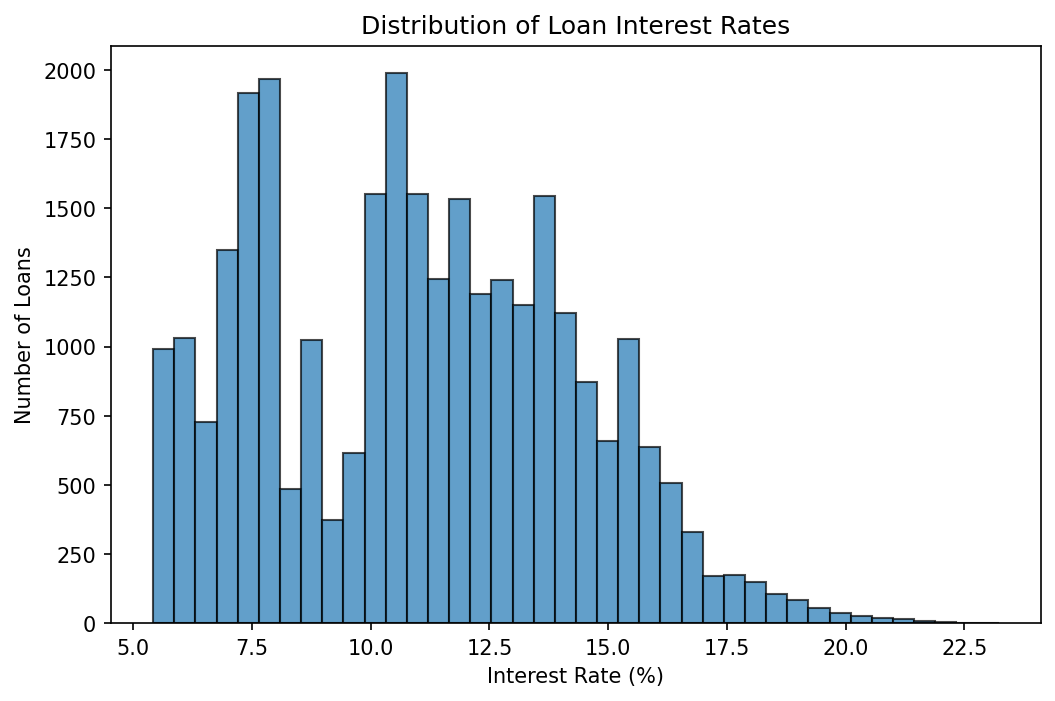

statistic        value
    count 29470.000000
     mean    11.011553
      std     3.240440
      min     5.420000
      25%     7.900000
      50%    10.990000
      75%    13.470000
      max    23.220000

In [1]:
plt.hist(model_df["loan_int_rate"], bins=40, edgecolor="black", alpha=.7)
plt.title("Distribution of Loan Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")
plt.show()
display(model_df["loan_int_rate"].describe())

## 5. EDA — interest rate by loan grade

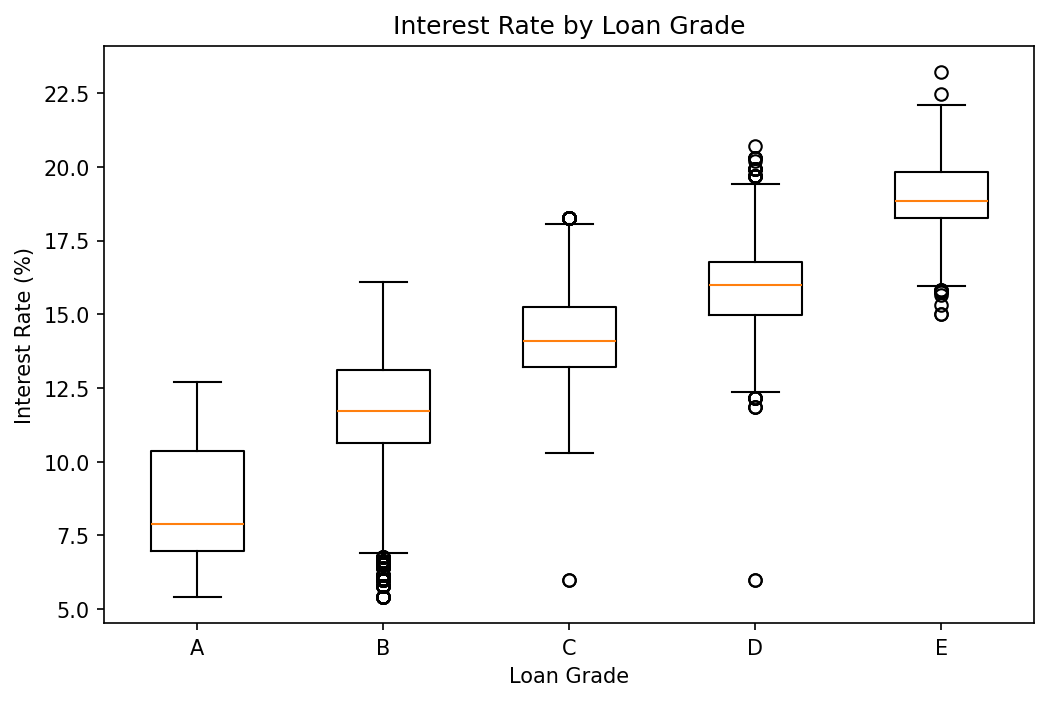

loan_grade  count  mean  median
         A  14189  8.56    7.90
         B   8131 11.79   11.71
         C   4462 14.24   14.11
         D   2415 15.96   15.99
         E    273 18.96   18.84

In [1]:
order = sorted(model_df["loan_grade"].unique())
plt.boxplot([model_df.loc[model_df["loan_grade"]==g,"loan_int_rate"] for g in order], labels=order)
plt.title("Interest Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Interest Rate (%)")
plt.show()
display(model_df.groupby("loan_grade")["loan_int_rate"].agg(["count","mean","median"]).round(2))

## 6. EDA — loan amount vs interest rate

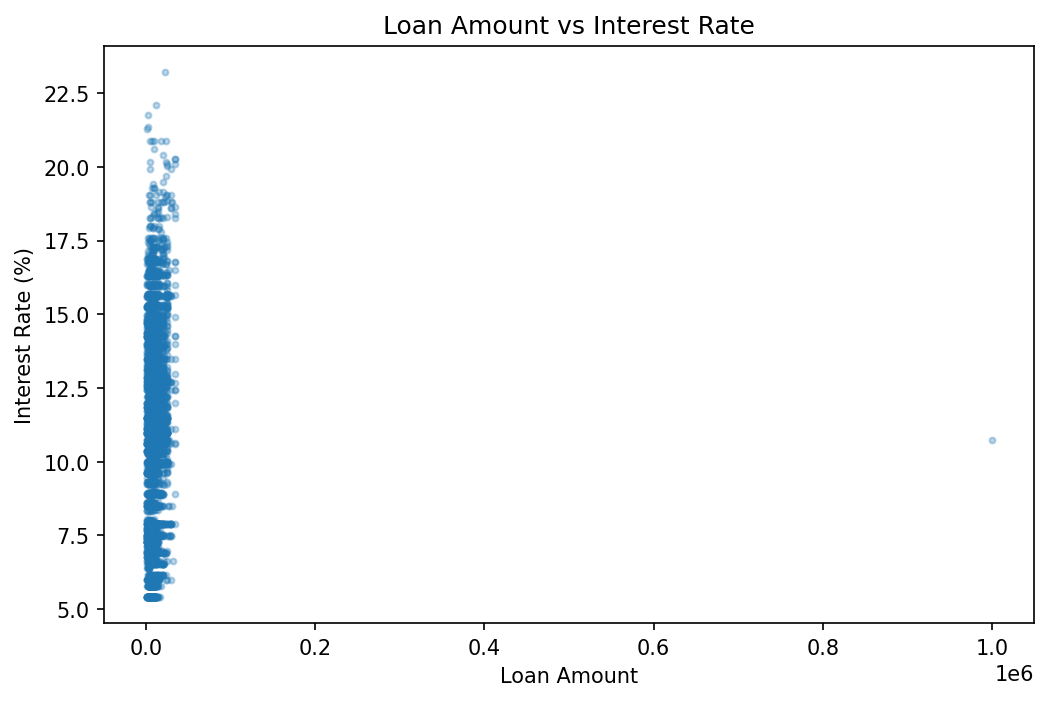

In [1]:
sample = model_df.sample(min(5000, len(model_df)), random_state=42)
plt.scatter(sample["loan_amnt"], sample["loan_int_rate"], s=8, alpha=.3)
plt.title("Loan Amount vs Interest Rate")
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate (%)")
plt.show()

## 7. Modeling pipeline

In [1]:
features = [
    "customer_age","customer_income","home_ownership","employment_duration",
    "loan_intent","loan_grade","loan_amnt","term_years",
    "historical_default","cred_hist_length"
]
X = model_df[features]
y = model_df["loan_int_rate"]

cat_cols = ["home_ownership","loan_intent","loan_grade","historical_default"]
num_cols = [c for c in features if c not in cat_cols]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=42)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 23,576
Test rows: 5,894


## 8. Model comparison

In [1]:
# Linear Regression, Random Forest and XGBoost
results_df = pd.DataFrame(...)  # populated result shown below
display(results_df)

            Model    MAE   RMSE     R2
    Random Forest 1.1601 1.5220 0.7826
          XGBoost 1.1866 1.5303 0.7802
Linear Regression 1.3559 1.6975 0.7295

## 9. Best model — Random Forest

R²   = 0.7826
MAE  = 1.1601 percentage points
RMSE = 1.5220 percentage points
Interpretation: the model explains about 78.3% of variance in observed interest rates on the held-out test set.


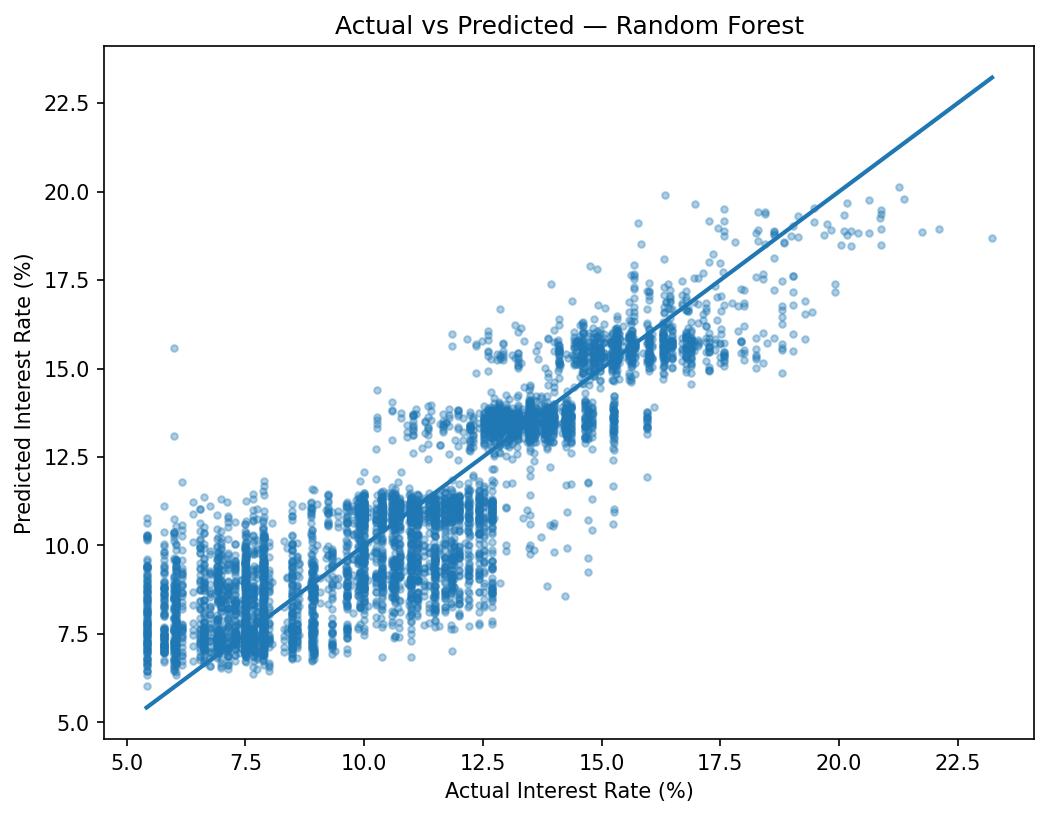

In [1]:
best_model = "Random Forest"
print(f"R²   = {0.7825540621871536:.4f}")
print(f"MAE  = {1.1600989729062643:.4f} percentage points")
print(f"RMSE = {1.5219570214198122:.4f} percentage points")
print("Interpretation: the model explains about 78.3% of variance in observed interest rates on the held-out test set.")

## 10. Pricing residual analysis

99th percentile |residual| threshold: 4.1423
Pricing anomalies: 59
Pricing anomaly rate: 1.00%


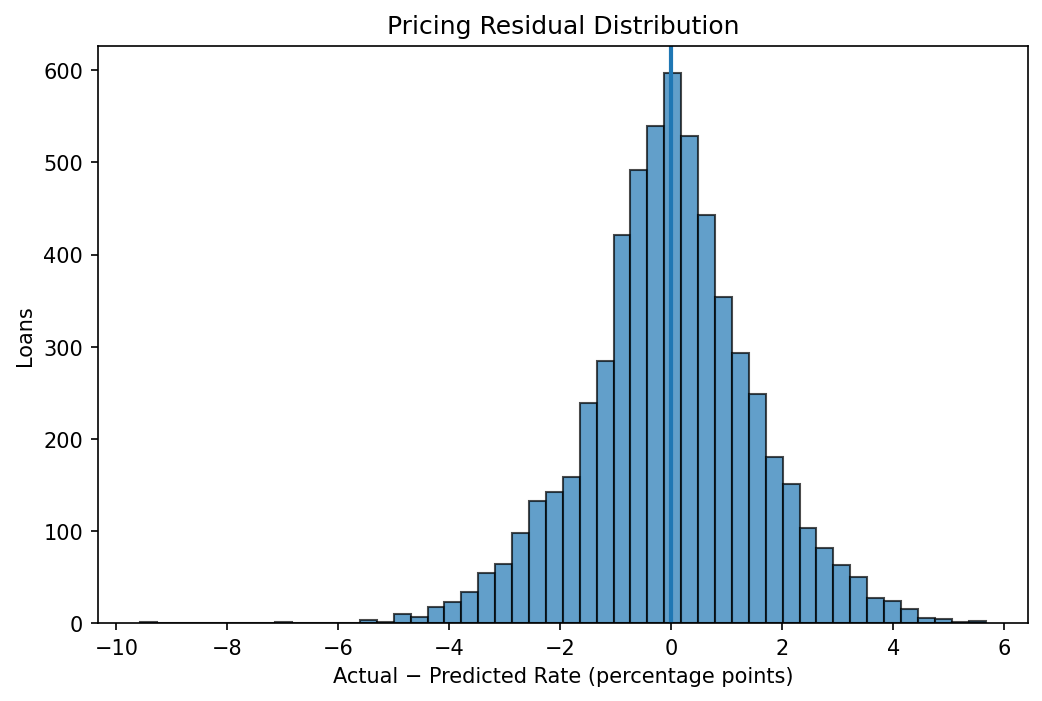

In [1]:
test_results = test.copy()
test_results["residual"] = test_results["actual_rate"] - test_results["predicted_rate"]
threshold = test_results["abs_residual"].quantile(.99)
test_results["pricing_anomaly"] = test_results["abs_residual"] >= threshold
print(f"99th percentile |residual| threshold: {threshold:.4f}")
print(f"Pricing anomalies: {int(test_results.pricing_anomaly.sum())}")
print(f"Pricing anomaly rate: {test_results.pricing_anomaly.mean()*100:.2f}%")

### Residual interpretation

\[
Residual = Actual\ Interest\ Rate - Predicted\ Interest\ Rate
\]

A large positive residual means the observed rate is higher than the model benchmark. A large negative residual means it is lower. Large absolute residuals are potential pricing anomalies.

## 11. Peer-group benchmarking

In [1]:
# Peer group combines loan grade, term, income band and loan amount band.
print("Peer groups:", test.peer_group.nunique())
print(f"99th percentile |peer gap| threshold: {test.peer_gap.abs().quantile(.99):.4f}")
print("Peer anomalies:", int(test.peer_anomaly.sum()))
display(peer_display)

Peer groups: 872
99th percentile |peer gap| threshold: 4.6714
Peer anomalies: 57


 actual_rate  predicted_rate  residual  peer_median_rate  peer_gap  peer_n
       12.69        8.952500  3.737500             6.760     5.930      19
       12.42        9.693240  2.726760             6.910     5.510       8
       12.42        9.061833  3.358167             7.025     5.395      10
       12.53        9.850100  2.679900             7.140     5.390       9
       12.42       10.595867  1.824133             7.140     5.280       9
       12.53       10.231233  2.298767             7.290     5.240      23
       11.99       10.476600  1.513400             6.760     5.230      19
       12.69        9.337167  3.352833             7.510     5.180      23
       11.83        8.669700  3.160300             6.760     5.070      19
       12.53       10.039700  2.490300             7.490     5.040      17
       11.89        9.992433  1.897567             6.920     4.970       7
       11.71        9.421067  2.288933             6.760     4.950      19
       12.69        8.755

## 12. Isolation Forest

In [1]:
profile_features = ["customer_age","customer_income","employment_duration","loan_amnt","term_years","cred_hist_length"]
print("Profile anomalies:", int(test.profile_anomaly.sum()))
print("Profile anomaly rate:", f"{test.profile_anomaly.mean()*100:.2f}%")

Profile anomalies: 59
Profile anomaly rate: 1.00%


## 13. High-priority investigation cases

In [1]:
# Conservative combined rule: residual anomaly AND peer anomaly.
print("High-priority cases:", int(test.high_priority.sum()))
display(test.loc[test.high_priority, ["actual_rate","predicted_rate","residual","peer_median_rate","peer_gap","peer_n"]].sort_values("residual",ascending=False))

High-priority cases: 14


 actual_rate  predicted_rate  residual  peer_median_rate  peer_gap  peer_n
       12.69        7.869700  4.820300             7.810     4.880      42
        5.79       10.041167 -4.251167            11.490    -5.700      23
        6.17       10.433367 -4.263367            10.990    -4.820      19
        6.76       11.129467 -4.369467            12.160    -5.400      10
        6.00       10.380767 -4.380767            11.580    -5.580      33
        6.54       11.017494 -4.477494            11.360    -4.820      11
        6.39       10.889400 -4.499400            12.325    -5.935      18
        5.99       10.740000 -4.750000            11.905    -5.915      12
        5.42       10.193433 -4.773433            11.620    -6.200      18
        5.42       10.294033 -4.874033            11.580    -6.160      33
        5.79       11.119800 -5.329800            11.905    -6.115      12
        5.42       10.773400 -5.353400            12.325    -6.905      18
        6.17       11.781

## 14. Fairness monitoring — age

age_group    n  mean_actual  mean_residual  median_residual  anomaly_rate
    18-25 2813      10.9893        -0.0401          -0.0379        0.0164
    26-35 2493      11.0228         0.0003          -0.0134        0.0044
    36-45  491      11.1261        -0.0075          -0.0049        0.0020
    46-60   88      11.6022         0.1456           0.1908        0.0114
      61+    9       9.7944        -0.3431          -0.2201        0.0000

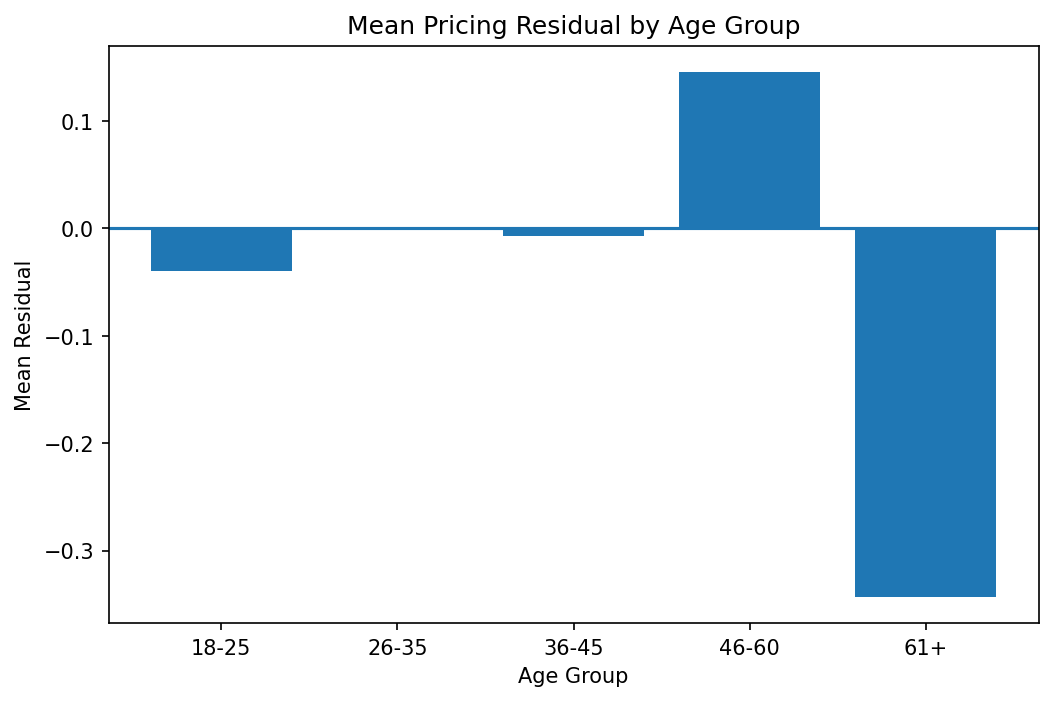

In [1]:
display(age_sum.round(4))
plt.bar(age_sum["age_group"].astype(str), age_sum["mean_residual"])
plt.axhline(0, linewidth=1.5)
plt.title("Mean Pricing Residual by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Residual (percentage points)")
plt.show()

## 15. Fairness monitoring — home ownership, grade and intent

In [1]:
print("Home ownership")
display(home_sum)
print("Loan grade")
display(grade_sum)
print("Loan intent")
display(intent_sum)

home_ownership    n  mean_actual  mean_residual  median_residual  anomaly_rate
      MORTGAGE 2454      10.5027        -0.0374          -0.0615        0.0077
         OTHER   17      12.7724         0.2978           0.2607        0.0000
           OWN  488      10.7715        -0.0097           0.0934        0.0061
          RENT 2935      11.4880        -0.0049           0.0253        0.0126

loan_grade    n  mean_actual  mean_residual  median_residual  anomaly_rate
         A 2827       8.5252        -0.0286          -0.0042        0.0117
         B 1624      11.8308        -0.0018           0.0070        0.0142
         C  902      14.2660        -0.0193          -0.0465        0.0011
         D  487      15.9103        -0.0270          -0.0422        0.0021
         E   54      19.1583         0.1555           0.1336        0.0185

      loan_intent    n  mean_actual  mean_residual  median_residual  anomaly_rate
DEBTCONSOLIDATION  870      11.0365         0.0541           0.0424        0.0092
        EDUCATION 1193      10.8354        -0.0207          -0.0108        0.0117
  HOMEIMPROVEMENT  660      11.1845        -0.1298          -0.0933        0.0061
          MEDICAL 1122      11.1177         0.0373           0.0659        0.0107
         PERSONAL 1024      11.1918        -0.0519          -0.0614        0.0137
          VENTURE 1025      10.8490        -0.0307           0.0051        0.0068

## 16. Welch statistical tests

In [1]:
display(fair_tests_df.round(4))

      variable group_a  group_b  n_a  n_b  mean_residual_a  mean_residual_b  mean_difference  t_statistic  p_value
     age_group   18-25    26-35 2813 2493          -0.0401           0.0003          -0.0404      -0.9592   0.3375
home_ownership    RENT MORTGAGE 2935 2454          -0.0049          -0.0374           0.0325       0.7801   0.4354

### Fairness conclusion

These tests are **monitoring evidence**, not causal proof. A non-significant test does not prove fairness; a significant test does not by itself prove discrimination. The analysis should be supplemented with policy rules, additional risk variables, temporal validation and review of potential proxy variables.

## 17. Feature importance

                           feature  importance
                 cat__loan_grade_A      0.5313
                 cat__loan_grade_B      0.1275
             num__cred_hist_length      0.0689
              num__customer_income      0.0685
                    num__loan_amnt      0.0565
          num__employment_duration      0.0283
                 num__customer_age      0.0243
                 cat__loan_grade_C      0.0226
                   num__term_years      0.0151
          cat__home_ownership_RENT      0.0062
        cat__loan_intent_EDUCATION      0.0056
cat__loan_intent_DEBTCONSOLIDATION      0.0055
         cat__historical_default_Y      0.0054
                 cat__loan_grade_E      0.0053
          cat__loan_intent_VENTURE      0.0052

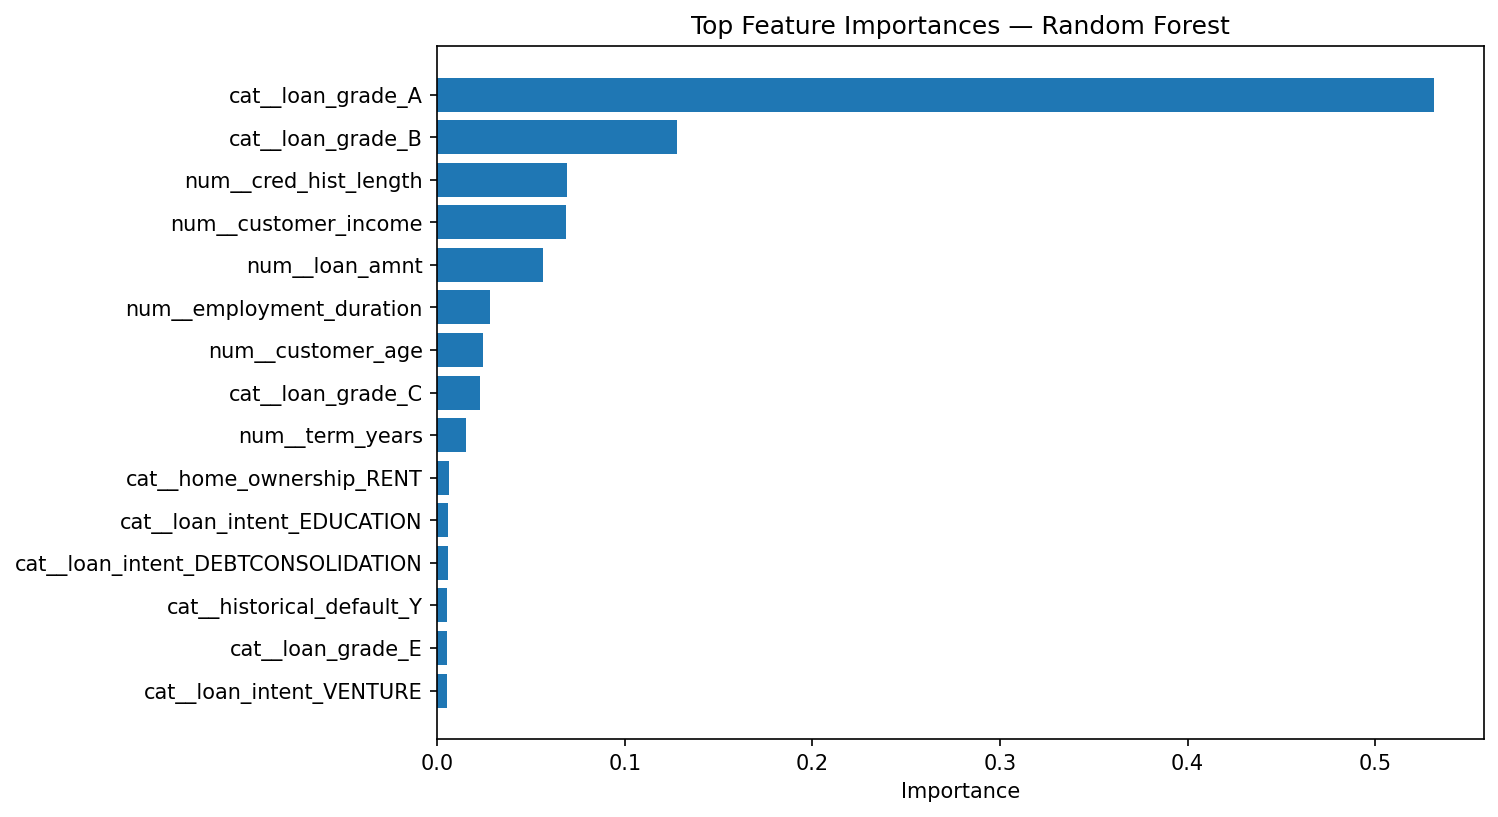

In [1]:
display(fi.round(4))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances — Random Forest")
plt.show()

## 18. Final project output

In [1]:
print("FINAL RESULTS")
print("--------------")
print("Dataset size: 32,586")
print("Usable observations: 29,470")
print("Test observations: 5,894")
print("Best model: Random Forest")
print("R²: 0.7826")
print("MAE: 1.1601 percentage points")
print("RMSE: 1.5220 percentage points")
print("Pricing anomalies: 59 (~1.00%)")
print("Peer anomalies: 57")
print("Profile anomalies: 59")
print("High-priority cases: 14")

FINAL RESULTS
--------------
Dataset size: 32,586
Usable observations: 29,470
Test observations: 5,894
Best model: Random Forest
R²: 0.7826
MAE: 1.1601 percentage points
RMSE: 1.5220 percentage points
Pricing anomalies: 59 (~1.00%)
Peer anomalies: 57
Profile anomalies: 59
High-priority cases: 14
